# Pseudotime trends of pathway & gene activity scores

Reproduces the pseudotime-trend animations from `rna_scoring_preproc.ipynb` in the human SKM multimodal repo, but driven entirely through `pygenelab`.

- Score DNA-damage / DNA-repair pathways with AUCell
- Smooth each score along pseudotime per `Annotation` group
- Animate a moving dot along the smoothed trace (MP4 if ffmpeg is on PATH, otherwise GIF)
- Same animator also drives a single-gene expression trace


In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

PYGENELAB_PARENT = Path("/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts")
if str(PYGENELAB_PARENT) not in sys.path:
    sys.path.insert(0, str(PYGENELAB_PARENT))

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
ad.settings.allow_write_nullable_strings = True
import matplotlib.pyplot as plt

import pygenelab as pgl

In [2]:
# ---- paths / config (edit for your environment) ----
adata_path = "/ix/djishnu/Akanksha/datasets/SKM_multimodal_ageing/objects/rna_female_type2_ds_wrt_HALLMARK_DNA_REPAIR.h5ad"
geneset_dir = "/ix/djishnu/Akanksha/datasets/gene_sets/gene_sets"
figures_dir = Path("/ix/djishnu/Akanksha/datasets/ERCC1_KO/figures/skm_female_human")
figures_dir.mkdir(parents=True, exist_ok=True)

pseudotime_key = "Pseudotime"
group_by_key = "Annotation"
lognorm_layer = "lognorm"  # set to None to use adata.X for gene-level animation

## Load adata

In [3]:
rna_adata = sc.read_h5ad(adata_path)
print(rna_adata)
rna_adata.obs[group_by_key].value_counts()

AnnData object with n_obs × n_vars = 3989 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'Pseudotime', 'Pseudotime_typeI', 'Pseudotime_typeII', 'bead_count', 'age_categorical', 'GOBP_DNA_DAMAGE_RESPONSE', 'GOBP_DNA_REPAIR', 'HALLMARK_DNA_REPAIR', 'REACTOME_DNA_REPAIR'
    var: 'features', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'score_aucell'
    varm: 'PCs'
    layers: 'counts', 'counts_float', 'lognorm'
    obsp: 'connectivities', 'distances'


Annotation
Type II        3391
ENOX1+ (II)     350
ID1+ (II)       241
DCLK1+ (II)       4
SAA2+ (II)        2
TNNT2+ (II)       1
Name: count, dtype: int64

## AUCell scoring of DNA-damage / DNA-repair pathways

Skip this section if AUCell scores are already in `adata.obs` (e.g. when reading a pre-scored h5ad).

In [4]:
dna_damage_pathways = [
    "GOBP_DNA_REPAIR",
    "GOBP_DNA_DAMAGE_RESPONSE",
    "REACTOME_DNA_REPAIR",
    "HALLMARK_DNA_REPAIR",
]

geneset_gmts = [
    os.path.join(geneset_dir, "human/DNA_repair/GOBP_DNA_REPAIR.v2024.1.Hs.gmt"),
    os.path.join(geneset_dir, "human/DNA_damage_response/GOBP_DNA_DAMAGE_RESPONSE.v2024.1.Hs.gmt"),
    os.path.join(geneset_dir, "human/DNA_repair/REACTOME_DNA_REPAIR.v2024.1.Hs.gmt"),
    os.path.join(geneset_dir, "human/DNA_repair/HALLMARK_DNA_REPAIR.v2024.1.Hs.gmt"),
]

missing_pathway_cols = [c for c in dna_damage_pathways if c not in rna_adata.obs.columns]
if missing_pathway_cols:
    print(f"Scoring {len(missing_pathway_cols)} missing pathways with AUCell...")
    geneset_df = pgl.geneset_from_gmts(geneset_gmts, gene_origin="human")
    pgl.report_geneset_overlap(geneset_df, rna_adata)
    pathways = pgl.score_geneset_aucell(
        rna_adata,
        geneset_df,
        raw=False,
        verbose=True,
        copy_to_obs=True,
    )
    print("Scored pathways:", pathways)
else:
    print("All DNA-damage pathway scores already present in adata.obs - skipping AUCell")

All DNA-damage pathway scores already present in adata.obs - skipping AUCell


In [5]:
# pathway sizes (used as subtitle annotation in the animation)
geneset_sizes_data = {
    "GOBP_DNA_REPAIR": 615,
    "GOBP_DNA_DAMAGE_RESPONSE": 906,
    "REACTOME_DNA_REPAIR": 332,
    "HALLMARK_DNA_REPAIR": 150,
}
geneset_sizes_series = pd.Series(geneset_sizes_data)
geneset_sizes_series

GOBP_DNA_REPAIR             615
GOBP_DNA_DAMAGE_RESPONSE    906
REACTOME_DNA_REPAIR         332
HALLMARK_DNA_REPAIR         150
dtype: int64

## Build cell-level scores DataFrame

In [6]:
obs_cols_keep = ["sample", "age", pseudotime_key, group_by_key]
obs_cols_keep = [c for c in obs_cols_keep if c in rna_adata.obs.columns]

cell_level_scores_df = rna_adata.obs[obs_cols_keep + dna_damage_pathways].copy()
cell_level_scores_df.head()

,sample,age,Pseudotime,Annotation,GOBP_DNA_REPAIR,GOBP_DNA_DAMAGE_RESPONSE,REACTOME_DNA_REPAIR,HALLMARK_DNA_REPAIR
CELL303_N2_1_1_6_1,OM6,80,70.0,Type II,0.063135,0.082709,0.056713,0.045641
CELL2900_N1_1_1_6_1,OM6,80,33.0,Type II,0.067559,0.082784,0.052412,0.059456
CELL2202_N1_1_1_6_1,OM6,80,94.0,ID1+ (II),0.067654,0.077198,0.067493,0.062925
CELL3194_N1_1_1_6_1,OM6,80,50.0,Type II,0.062191,0.082652,0.042180,0.045380
CELL523_N2_1_1_6_1,OM6,80,91.0,Type II,0.087379,0.095432,0.062522,0.067139


## Animation: pathway score vs pseudotime

Starting animation creation...


2026-05-28 13:56:47 | [INFO] Animation.save using <class 'matplotlib.animation.PillowWriter'>


Figure created with 1 animated lines
Creating animation with 200 frames at 30 fps...
Saving as GIF to /ix/djishnu/Akanksha/datasets/ERCC1_KO/figures/skm_female_human/pathway_animation.gif...
GIF saved successfully
Animation creation complete


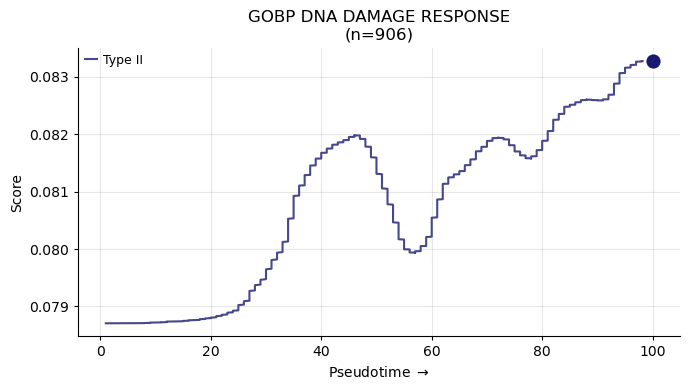

In [7]:
plot_colors = {"Type II": "#191970"}
legend_labels = {"Type II": "Type II"}

score_cols_to_plot = ["GOBP_DNA_DAMAGE_RESPONSE"]

anim_result = pgl.create_animated_pathway_plot(
    df_cell_level=cell_level_scores_df,
    score_cols=score_cols_to_plot,
    pseudotime_key=pseudotime_key,
    group_by_key=group_by_key,
    smoothing_method="gaussian",
    smoothing_strength=120.0,
    geneset_sizes=geneset_sizes_series,
    groups_to_plot=["Type II"],
    colors_dict=plot_colors,
    legend_labels_map=legend_labels,
    n_subplot_cols=1,
    figsize_per_subplot=(7, 4),
    nframes=200,
    fps=30,
    dot_size=150,
    output_file=str(figures_dir / "pathway_animation.mp4"),
    use_gif=None,  # autodetect ffmpeg, fall back to GIF
)
print("Animation creation complete")

Starting animation creation...
Figure created with 4 animated lines
Creating animation with 200 frames at 30 fps...


2026-05-28 13:57:18 | [INFO] Animation.save using <class 'matplotlib.animation.PillowWriter'>


Saving as GIF to /ix/djishnu/Akanksha/datasets/ERCC1_KO/figures/skm_female_human/dna_damage_pathways_animation.gif...
GIF saved successfully


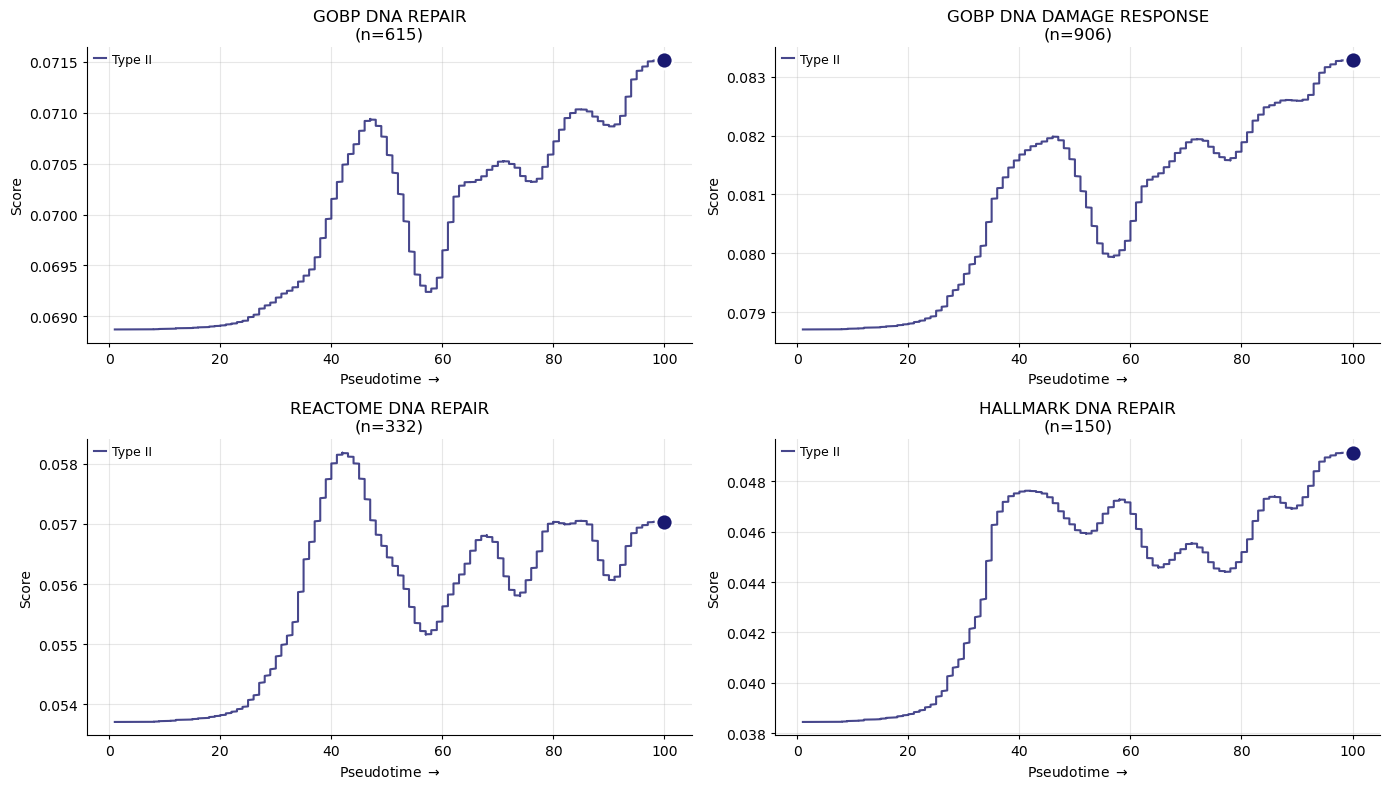

In [8]:
# all four DNA-damage / DNA-repair pathways in a 2x2 grid
anim_result_multi = pgl.create_animated_pathway_plot(
    df_cell_level=cell_level_scores_df,
    score_cols=dna_damage_pathways,
    pseudotime_key=pseudotime_key,
    group_by_key=group_by_key,
    smoothing_method="gaussian",
    smoothing_strength=120.0,
    geneset_sizes=geneset_sizes_series,
    groups_to_plot=["Type II"],
    colors_dict=plot_colors,
    legend_labels_map=legend_labels,
    n_subplot_cols=2,
    figsize_per_subplot=(7, 4),
    nframes=200,
    fps=30,
    dot_size=150,
    output_file=str(figures_dir / "dna_damage_pathways_animation.mp4"),
    use_gif=None,
)

## Animation: single-gene expression vs pseudotime

In [ ]:
gene_of_interest = "PDK4"

anim_gene = pgl.animate_gene_along_pseudotime(
    rna_adata,
    genes=gene_of_interest,
    pseudotime_key=pseudotime_key,
    group_by_key=group_by_key,
    layer=lognorm_layer,
    smoothing_strength=120.0,
    groups_to_plot=["Type II"],
    colors_dict=plot_colors,
    legend_labels_map=legend_labels,
    output_file=str(figures_dir / f"{gene_of_interest.lower()}_animation.mp4"),
    use_gif=None,
)

2026-05-28 13:59:13 | [INFO] Animation.save using <class 'matplotlib.animation.PillowWriter'>


Starting animation creation...
Figure created with 1 animated lines
Creating animation with 200 frames at 30 fps...
Saving as GIF to /ix/djishnu/Akanksha/datasets/ERCC1_KO/figures/skm_female_human/pdk4_animation.gif...


In [ ]:
# multiple genes in one grid
goi_list = ["PDK4", "IRS2", "NR4A3", "FABP4"]
goi_list = [g for g in goi_list if g in rna_adata.var_names]

anim_gene_multi = pgl.animate_gene_along_pseudotime(
    rna_adata,
    genes=goi_list,
    pseudotime_key=pseudotime_key,
    group_by_key=group_by_key,
    layer=lognorm_layer,
    smoothing_strength=120.0,
    groups_to_plot=["Type II"],
    colors_dict=plot_colors,
    legend_labels_map=legend_labels,
    n_subplot_cols=2,
    output_file=str(figures_dir / "goi_animation.mp4"),
    use_gif=None,
)